In [3]:
import pandas as pd
df = pd.read_csv('time_series_health_data.csv')
df

,timestamp,patient_id,temperature,heart_rate,blood_oxygen,status
0,440,V6,36.500000,97.373652,95.377976,risky
1,445,V6,36.600002,101.604314,95.377976,risky
2,450,V6,36.600002,101.329558,95.377976,risky
3,455,V6,36.600002,101.545110,95.377976,risky
4,460,V6,36.600002,99.492086,95.377976,risky
...,...,...,...,...,...,...
5183,24865,V94,36.799999,62.000000,98.000000,healthy
5184,24890,V94,36.799999,63.000000,99.000000,healthy
5185,24895,V94,36.799999,67.000000,100.000000,healthy
5186,24900,V94,36.799999,66.000000,100.000000,healthy



===== DATA OVERVIEW =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5188 entries, 0 to 5187
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     5188 non-null   datetime64[ns]
 1   patient_id    5188 non-null   object        
 2   temperature   5188 non-null   float64       
 3   heart_rate    5188 non-null   float64       
 4   blood_oxygen  5188 non-null   float64       
 5   status        5188 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(3), object(1)
memory usage: 208.0+ KB
None

===== FIRST ROWS =====
            timestamp patient_id  temperature  heart_rate  blood_oxygen status
0 1970-01-01 00:07:20         V6    36.500000   97.373652     95.377976  risky
1 1970-01-01 00:07:25         V6    36.600002  101.604314     95.377976  risky
2 1970-01-01 00:07:30         V6    36.600002  101.329558     95.377976  risky
3 1970-01-01 00:07:35         V6    

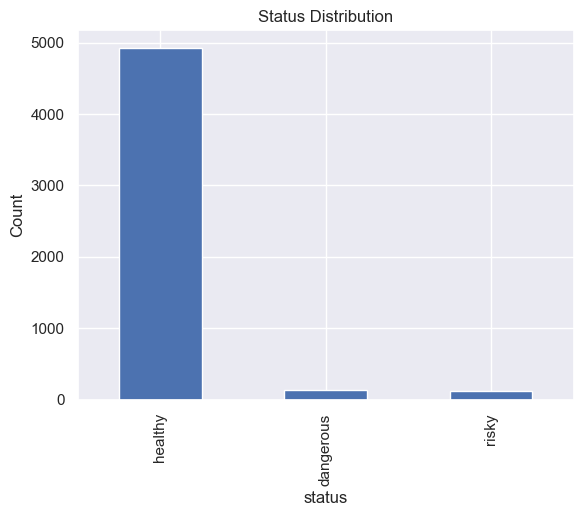

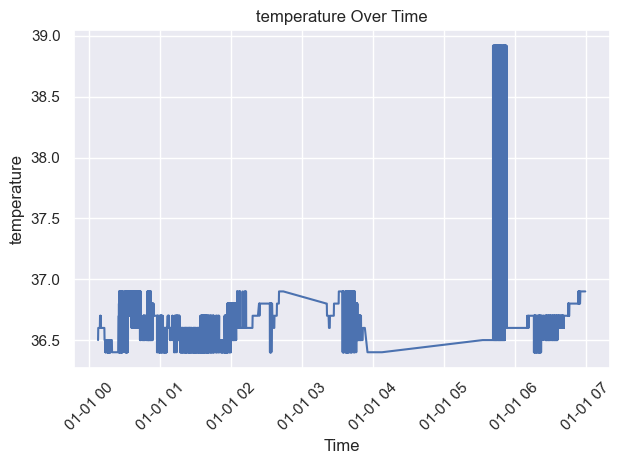

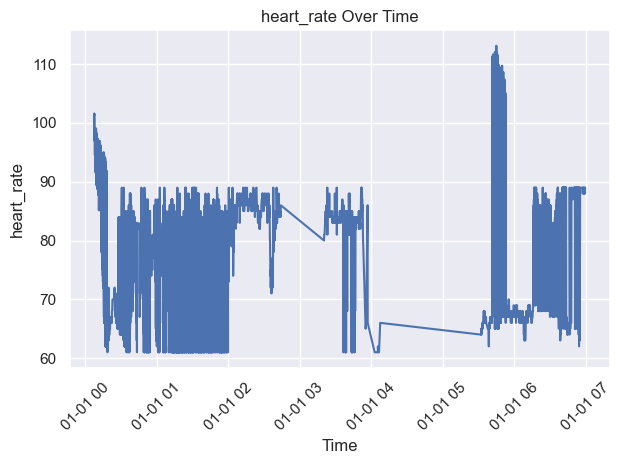

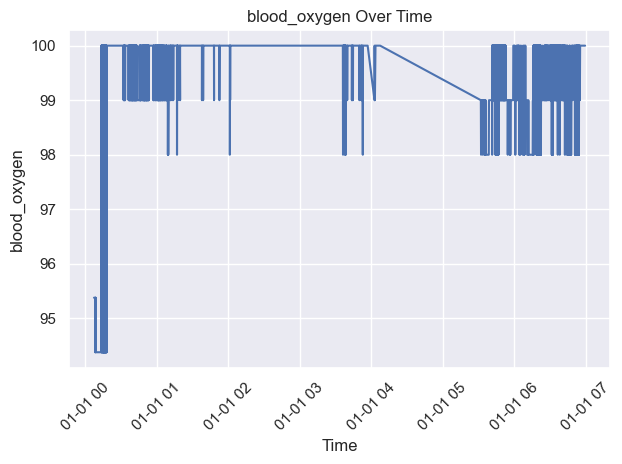

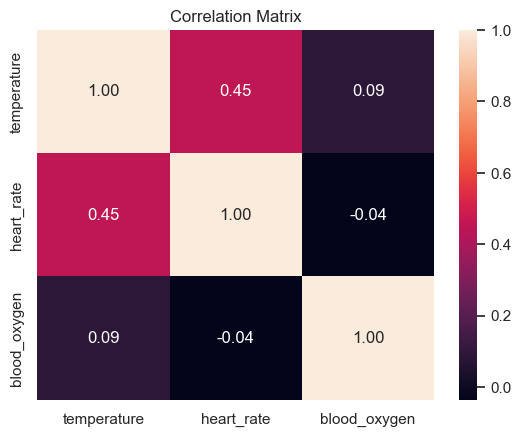

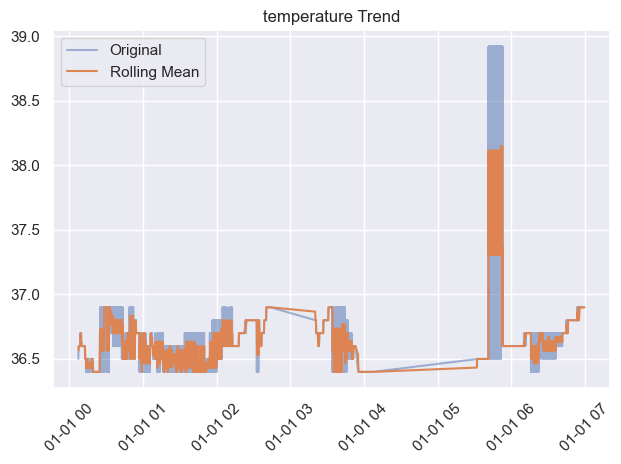

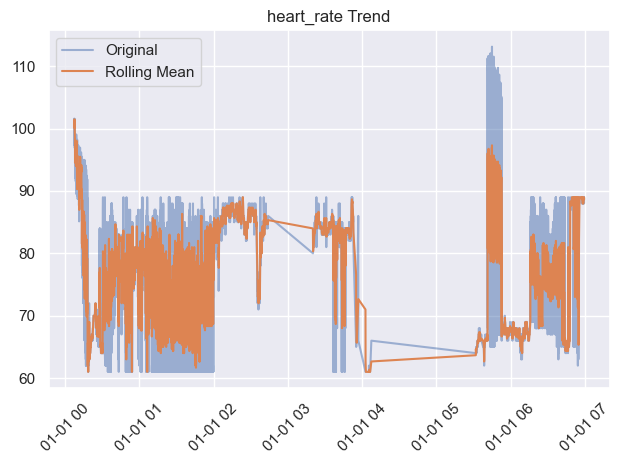

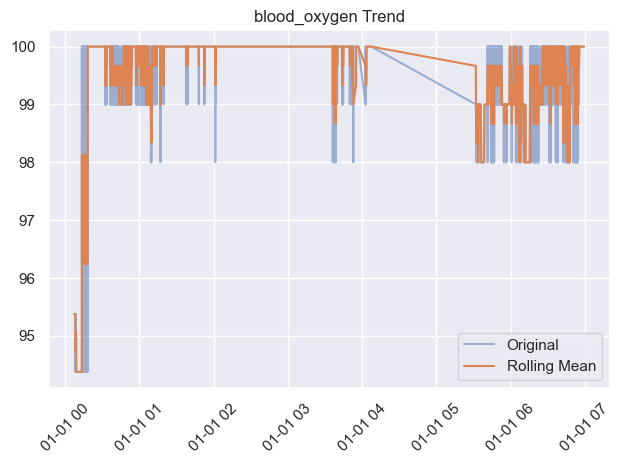


===== OUTLIER COUNT (Z > 3) =====
temperature     135
heart_rate       29
blood_oxygen    128
dtype: int64


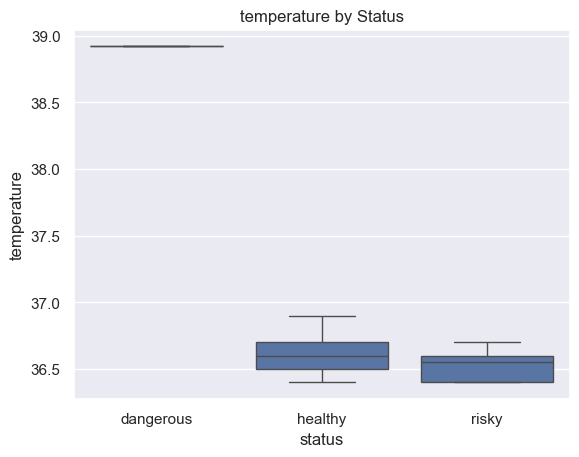

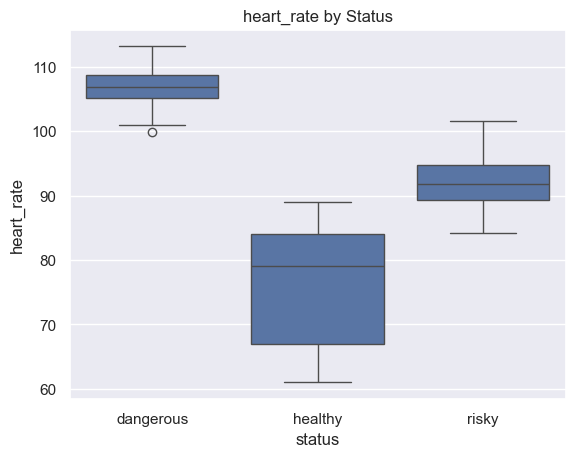

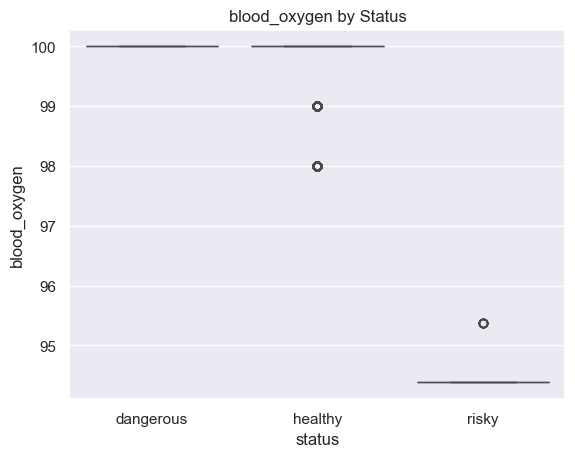


===== FINAL SUMMARY =====
Total Records: 5188
Patients: 10
Time Range: 1970-01-01 00:07:20 to 1970-01-01 06:59:30


In [4]:
# ===============================
# 1. Imports
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

# ===============================
# 2. Load Data
# ===============================
# If loading from CSV:
# df = pd.read_csv("your_file.csv")

# Ensure correct datatypes
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
df['patient_id'] = df['patient_id'].astype(str)
df['status'] = df['status'].astype('category')

# Sort chronologically
df = df.sort_values("timestamp").reset_index(drop=True)

# ===============================
# 3. Basic Overview
# ===============================
print("\n===== DATA OVERVIEW =====")
print(df.info())

print("\n===== FIRST ROWS =====")
print(df.head())

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# ===============================
# 4. Status Distribution
# ===============================
print("\n===== STATUS DISTRIBUTION =====")
print(df['status'].value_counts())

plt.figure()
df['status'].value_counts().plot(kind='bar')
plt.title("Status Distribution")
plt.ylabel("Count")
plt.show()

# ===============================
# 5. Vital Signs Over Time
# ===============================
vitals = ['temperature', 'heart_rate', 'blood_oxygen']

for col in vitals:
    plt.figure()
    plt.plot(df['timestamp'], df[col])
    plt.title(f"{col} Over Time")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ===============================
# 7. Correlation Analysis
# ===============================
numeric_cols = ['temperature', 'heart_rate', 'blood_oxygen']

corr = df[numeric_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# ===============================
# 8. Rolling Trend Analysis
# ===============================
window = 3  # Adjust based on sampling rate

rolling_df = df[numeric_cols].rolling(window=window).mean()

for col in numeric_cols:
    plt.figure()
    plt.plot(df['timestamp'], df[col], alpha=0.5, label='Original')
    plt.plot(df['timestamp'], rolling_df[col], label='Rolling Mean')
    plt.title(f"{col} Trend")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ===============================
# 9. Outlier Detection (Z-score)
# ===============================
from scipy.stats import zscore

z_scores = np.abs(zscore(df[numeric_cols]))
outliers = (z_scores > 3)

outlier_counts = pd.DataFrame(outliers, columns=numeric_cols).sum()
print("\n===== OUTLIER COUNT (Z > 3) =====")
print(outlier_counts)

# ===============================
# 10. Relationship with Status
# ===============================
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x='status', y=col, data=df)
    plt.title(f"{col} by Status")
    plt.show()

# ===============================
# 11. Summary Report
# ===============================
print("\n===== FINAL SUMMARY =====")
print(f"Total Records: {len(df)}")
print(f"Patients: {df['patient_id'].nunique()}")
print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
